1. IMPORTS

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score


2. LOAD AND CLEAN DATA

In [2]:
df = pd.read_csv("C:\\Users\\HP-PC\\Downloads\\log.csv")
df.head()
df = df.drop_duplicates()
df = df.fillna(df.mean(numeric_only=True))

df = df[df['DPOR'] >= 0]
df = df[df['RHOB'] > 0]
df = df[df['CNLS'] >= 0]

print(df.shape)



(8682, 14)


3. FEATURE SELECTION AND SCALING

In [3]:
features = ['Depth','GR', 'DPOR', 'RHOB', 'RILD', 'SP']
X = df[features]
from sklearn.preprocessing import StandardScaler

X_train, X_test = train_test_split(
    X,
    train_size=0.3,
    random_state=42
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


4. BIC CALCULATION

In [4]:
import warnings
warnings.filterwarnings("ignore")

bic_scores = []
cluster_range = range(1, 7)

for k in cluster_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42
    )
    gmm.fit(X_train_scaled)
    bic_scores.append(gmm.bic(X_train_scaled))


5. PLOTTING BIC

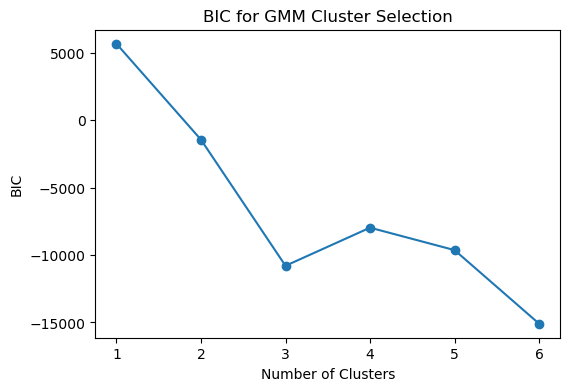

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(cluster_range, bic_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("BIC")
plt.title("BIC for GMM Cluster Selection")
plt.show()


In [6]:
gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_train_scaled)
X_full_scaled = scaler.transform(X)

df['Facies_GMM'] = gmm.predict(X_full_scaled)



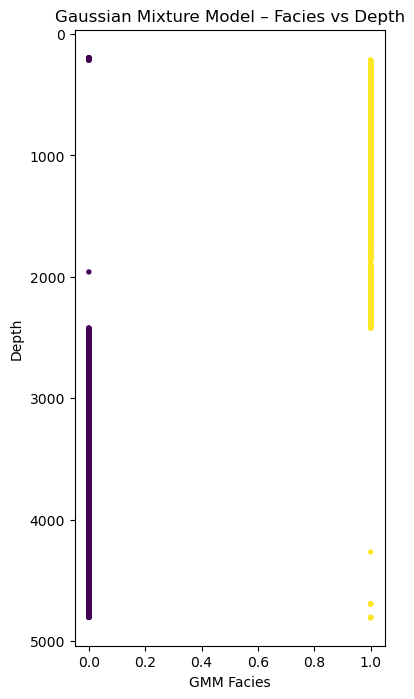

In [7]:
plt.figure(figsize=(4, 8))
plt.scatter(
    df['Facies_GMM'],
    df['Depth'],
    c=df['Facies_GMM'],
    cmap='viridis',
    s=8
)
plt.gca().invert_yaxis()
plt.xlabel("GMM Facies")
plt.ylabel("Depth")
plt.title("Gaussian Mixture Model – Facies vs Depth")
plt.show()


In [8]:
df.groupby('Facies_GMM')[['Depth','GR', 'RILD', 'RHOB', 'DPOR', 'SP']].mean()
#0 = shale  
#1 = sandstone

,Depth,GR,RILD,RHOB,DPOR,SP
Facies_GMM,,,,,,
0,3585.957478,73.280386,22.949880,2.227592,28.211015,-69.148373
1,1249.387794,82.056634,42.793521,1.796902,53.397520,-124.684972


In [9]:
df['GMM_Max_Prob'] = gmm.predict_proba(X_full_scaled).max(axis=1)



In [10]:
test_clusters = gmm.predict(X_test_scaled)

score = silhouette_score(X_test_scaled, test_clusters)
print("Test Silhouette Score:", score)


Test Silhouette Score: 0.342493051719444


In [11]:
folder_path = os.path.abspath("saved_models")
os.makedirs(folder_path, exist_ok=True)

gmm_path = os.path.join(folder_path, "gmm.pkl")
scaler_path = os.path.join(folder_path, "gmm_scaler.pkl")

joblib.dump(gmm, gmm_path)
joblib.dump(scaler, scaler_path)

print("GMM model saved successfully.")


GMM model saved successfully.


In [12]:
df['Model'] = 'Gaussian Mixture Model'
df['sand_score'] = None  # optional, keep consistent

df.to_csv("gmm_output.csv", index=False)

